# Data Loading

In [45]:
import pandas as pd
import numpy as np
import re
from collections import deque

In [46]:
btest_csv_file=r'c:\Users\andrej\Downloads\df_lag.csv' 
prod_log_file=r'c:\Users\andrej\Downloads\autotrader_child_2.log.2025-05-05T11_13_34.984668'

In [47]:
btest=pd.read_csv(btest_csv_file, index_col=0)
btest["datetime"] = pd.to_datetime(btest["datetime"])  # Convert if it's a string

start_time = pd.Timestamp("2025-05-05T10:00:25.803560")
end_time = pd.Timestamp("2025-05-05T11:00:25.803560")

# Filter the DataFrame
btest = btest[(btest["tag"] == 'trades')]
btest = btest[(btest["datetime"] >= start_time) & (btest["datetime"] <= end_time)]
#btest = btest[btest['trd_price'].isnull()==False]


# Identify rows where bid_price and ask_price are the same as the previous row
#same_prices = (btest["bid_price"] == btest["bid_price"].shift()) & (btest["ask_price"] == btest["ask_price"].shift())

# Identify rows where neither the current nor the previous row has a trade price
#no_trade = btest["trd_price"].isna() & btest["trd_price"].shift().isna()

## Remove rows where both conditions hold (consecutive bid/ask prices & no trades)
#btest = btest[~(same_prices & no_trade)]

In [48]:
# Define regex pattern for extracting relevant lines
pattern = re.compile(
    r"(?P<timestamp>\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+) \[.*?\] DEBUG .*?: Action calculated: action (?P<action>-?\d+), : "
    r"MACD (?P<MACD>-?\d+\.\d+), bid_macd (?P<bid_macd>-?\d+\.\d+),"
    r"bid_volatility (?P<bid_volatility>-?\d+\.\d+),ask_macd (?P<ask_macd>-?\d+\.\d+),"
    r"ask_volatility (?P<ask_volatility>-?\d+\.\d+),ba_spread (?P<ba_spread>-?\d+\.\d+),intensity (?P<intensity>-?\d+\.\d+),"
)

# List to store parsed data
data = []

# Store previous 10 lines
history = deque(maxlen=10)

# Read and parse the log file
with open(prod_log_file, "r") as file:
    for line in file:
        match = pattern.search(line)
        if match:
        # Check previous 10 lines for the trigger line
            if any("DEBUG On Public Trade Update" in prev_line for prev_line in history):
                data.append(match.groupdict())

        history.append(line)
            
# Convert extracted data into a DataFrame
prod = pd.DataFrame(data)

# Convert timestamp to datetime
prod["timestamp"] = pd.to_datetime(prod["timestamp"])
prod["datetime"] = prod["timestamp"]

prod = prod[(prod["datetime"] >= start_time) & (prod["datetime"] <= end_time)]
# Convert numeric columns to float
for col in prod.columns[1:-2]:  # Skip 'timestamp' column
    prod[col] = prod[col].astype(float)

In [49]:
btest.head(50)

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,timestamp,date,...,MACD_30_60,tag,VII_lag_3,VII_lag_5,VII_lag_10,bid_macd,bid_volatility,ask_macd,ask_volatility,ba_spread
414062,2025-05-05 10:00:39.815550661,NaN,NaN,75.19,75.42,75.305,NaN,65.282000,2025-05-05 10:00:33.113000000,2025-05-05,...,-0.052384,trades,0.745988,0.987009,NaN,-0.000113,0.03,-0.001663,0.14,0.23
414063,2025-05-05 10:00:42.174462607,NaN,NaN,75.19,75.42,75.305,NaN,65.282000,2025-05-05 10:00:33.113000000,2025-05-05,...,-0.052384,trades,0.745988,0.987009,NaN,-0.000113,0.03,-0.001663,0.14,0.23
414064,2025-05-05 10:00:44.630063078,NaN,NaN,75.19,75.42,75.305,NaN,65.282000,2025-05-05 10:00:33.113000000,2025-05-05,...,-0.052384,trades,0.745988,0.987009,NaN,-0.000113,0.03,-0.001663,0.14,0.23
414065,2025-05-05 10:00:44.632273072,NaN,NaN,75.19,75.42,75.305,NaN,65.282000,2025-05-05 10:00:33.113000000,2025-05-05,...,-0.052384,trades,0.745988,0.987009,NaN,-0.000113,0.03,-0.001663,0.14,0.23
414066,2025-05-05 10:00:44.641235538,NaN,NaN,75.19,75.42,75.305,NaN,65.282000,2025-05-05 10:00:33.113000000,2025-05-05,...,-0.052384,trades,0.745988,0.987009,NaN,-0.000113,0.03,-0.001663,0.14,0.23
414067,2025-05-05 10:00:44.643715254,NaN,NaN,75.19,75.42,75.305,NaN,65.282000,2025-05-05 10:00:33.113000000,2025-05-05,...,-0.052384,trades,0.745988,0.987009,NaN,-0.000113,0.03,-0.001663,0.14,0.23
414068,2025-05-05 10:00:44.729000000,NaN,NaN,75.19,75.41,75.300,NaN,11.599000,2025-05-05 10:00:44.712000000,2025-05-05,...,-0.052384,trades,0.743516,0.985780,NaN,0.000884,0.03,-0.000523,0.14,0.22
414069,2025-05-05 10:01:43.792975301,NaN,NaN,75.16,75.32,75.240,NaN,0.770000,2025-05-05 10:01:38.642000000,2025-05-05,...,-0.052384,trades,0.732647,0.980317,NaN,-0.005732,0.08,-0.019385,0.10,0.16
414070,2025-05-05 10:01:43.793103325,NaN,NaN,75.17,75.32,75.245,NaN,5.151000,2025-05-05 10:01:43.793000000,2025-05-05,...,-0.052384,trades,0.731659,0.979816,NaN,-0.003260,0.08,-0.018559,0.09,0.15
414071,2025-05-05 10:01:43.888477444,NaN,NaN,75.19,75.32,75.255,NaN,0.079000,2025-05-05 10:01:43.872000000,2025-05-05,...,-0.052384,trades,0.731644,0.979808,NaN,0.001119,0.08,-0.017466,0.07,0.13


In [50]:
prod.head(50)

,timestamp,action,MACD,bid_macd,bid_volatility,ask_macd,ask_volatility,ba_spread,intensity,datetime
0,2025-05-05 10:13:44.103643,0.0,-0.1952,-0.0421,0.35,-0.0348,0.26,0.26,0.7511,2025-05-05 10:13:44.103643
1,2025-05-05 10:13:44.236286,0.0,-0.1952,-0.0421,0.35,-0.0348,0.26,0.26,0.7511,2025-05-05 10:13:44.236286
2,2025-05-05 10:13:53.422739,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7502,2025-05-05 10:13:53.422739
3,2025-05-05 10:14:01.283130,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7493,2025-05-05 10:14:01.283130
4,2025-05-05 10:14:01.318233,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7493,2025-05-05 10:14:01.318233
5,2025-05-05 10:14:25.407880,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7469,2025-05-05 10:14:25.407880
6,2025-05-05 10:14:26.530762,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7467,2025-05-05 10:14:26.530762
7,2025-05-05 10:14:26.544462,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7467,2025-05-05 10:14:26.544462
8,2025-05-05 10:14:30.474110,0.0,-0.1952,-0.0445,0.38,-0.0639,0.31,0.24,0.7463,2025-05-05 10:14:30.474110
9,2025-05-05 10:14:30.489298,0.0,-0.1952,-0.0445,0.38,-0.0639,0.31,0.24,0.7463,2025-05-05 10:14:30.489298


# Examining difference

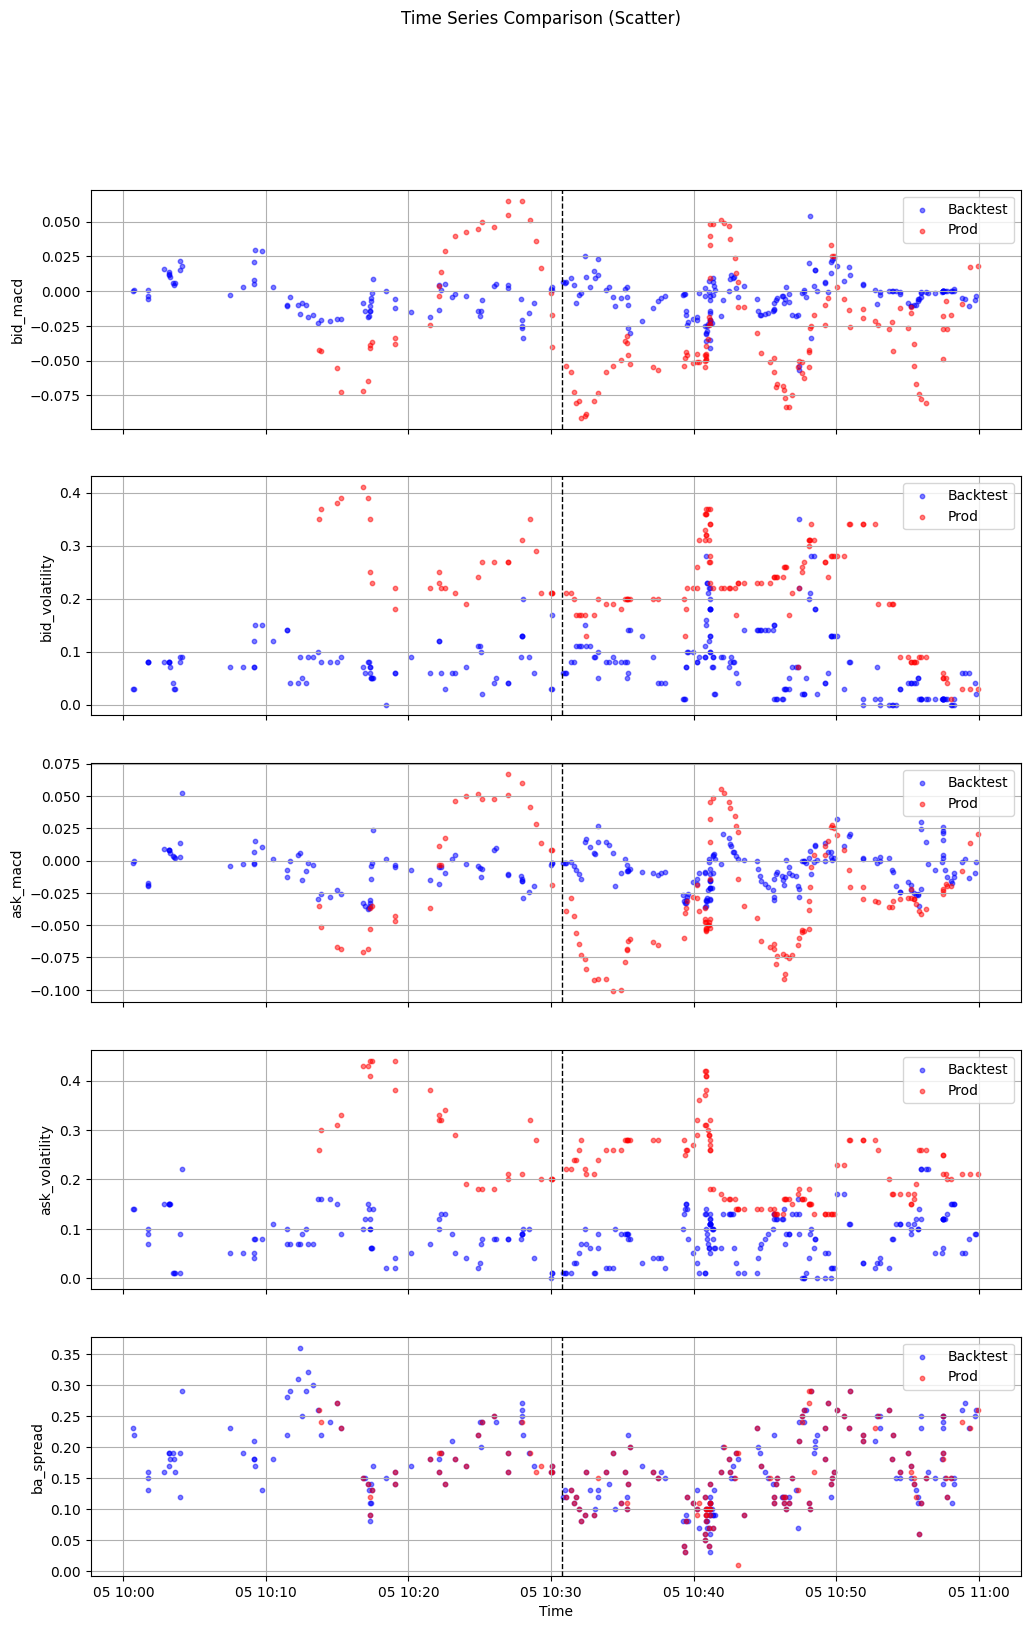

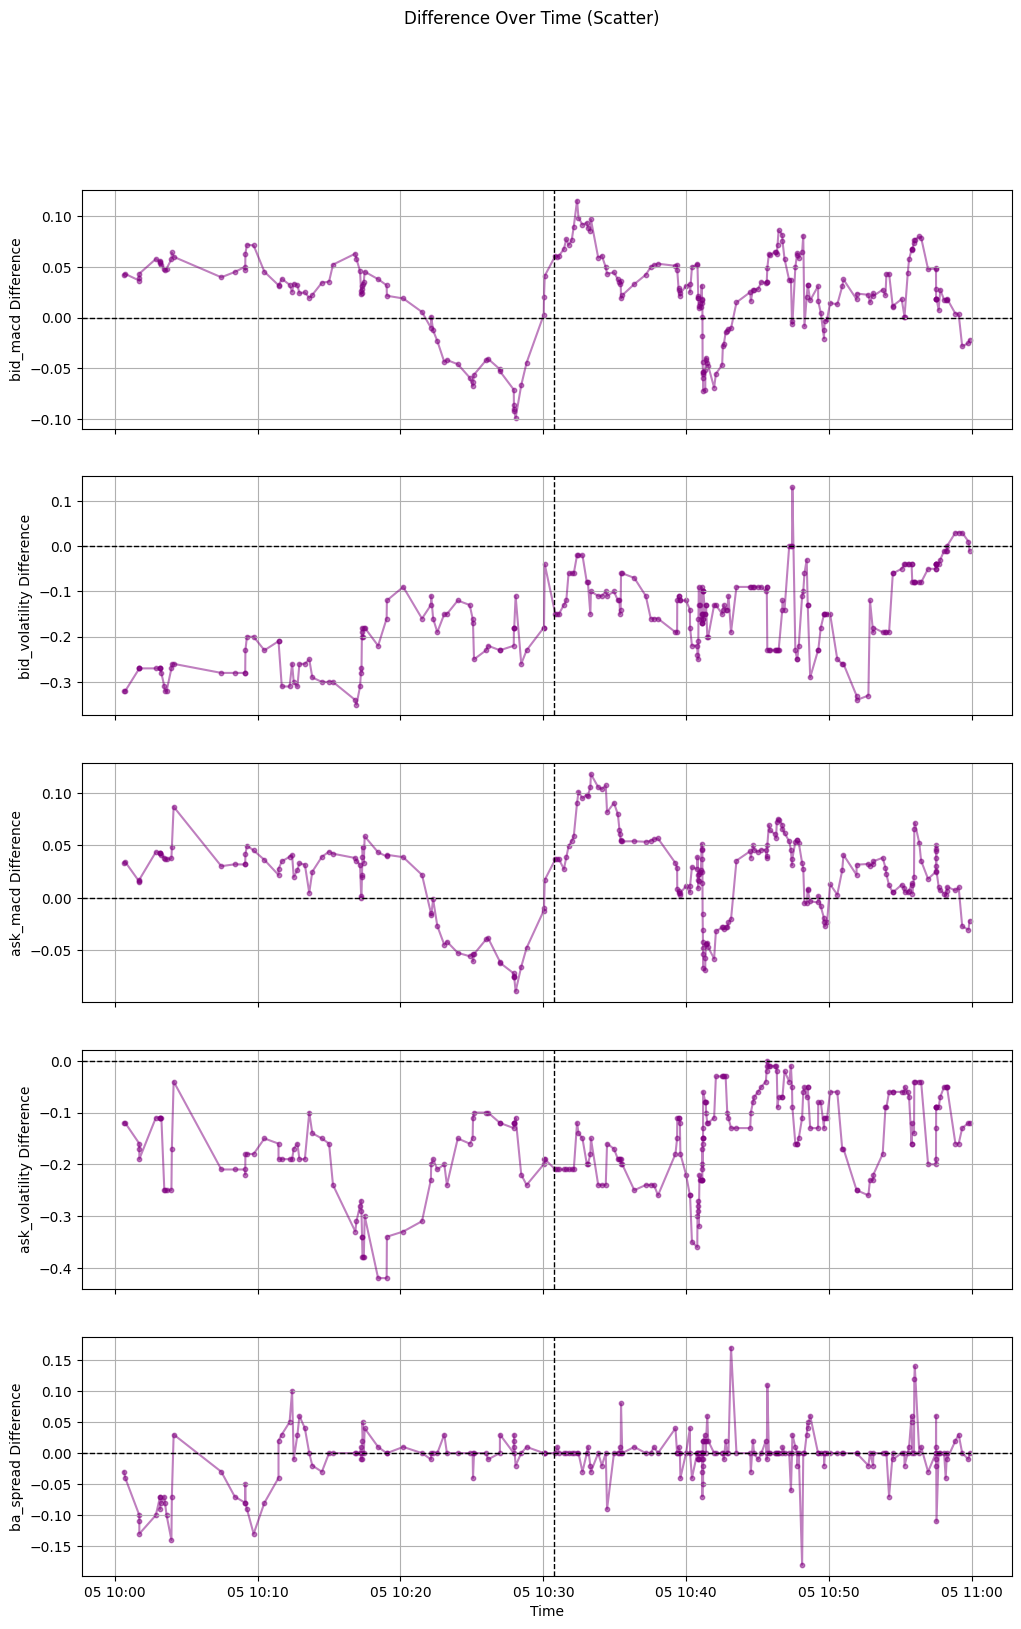

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert datetime columns
btest["datetime"] = pd.to_datetime(btest["datetime"])
prod["datetime"] = pd.to_datetime(prod["datetime"])

# Sort both datasets by time (important for merge_asof)
btest = btest.sort_values("datetime")
prod = prod.sort_values("datetime")

prod['ba_spread_diff'] = prod['ba_spread'].diff()
prod = prod[prod['ba_spread_diff'] != 0]

btest['ba_spread_diff'] = btest['ba_spread'].diff()
btest = btest[btest['ba_spread_diff'] != 0]


# Merge using nearest timestamp
df_merged = pd.merge_asof(btest, prod, on="datetime", direction="nearest", suffixes=("_btest", "_prod"))

# Compute differences
for col in ["bid_macd", "bid_volatility", "ask_macd", "ask_volatility", "ba_spread"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_btest"] - df_merged[f"{col}_prod"]

# Define the vertical line timestamp
vline_time = pd.Timestamp("2025-05-05T10:30:45.292575")

### 1️⃣ **Time Series Comparison (Scatter Plot)**
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

for i, col in enumerate(["bid_macd", "bid_volatility", "ask_macd", "ask_volatility", "ba_spread"]):
    #axes[i].plot(btest["datetime"], btest[f"{col}"], label="Backtest", color="blue", alpha=0.5)
    #axes[i].plot(prod["datetime"], prod[f"{col}"], label="Prod", color="red", alpha=0.5)
    axes[i].scatter(btest["datetime"], btest[f"{col}"], label="Backtest", color="blue", alpha=0.5, s=10)
    axes[i].scatter(prod["datetime"], prod[f"{col}"], label="Prod", color="red", alpha=0.5, s=10)
    axes[i].axvline(vline_time, color="black", linestyle="dashed", linewidth=1)  # Vertical line at timestamp
    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True)

plt.xlabel("Time")
plt.suptitle("Time Series Comparison (Scatter)")
plt.show()

# ### 2️⃣ **Histogram Comparison (No Change Needed)**
# fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=False)

# for i, col in enumerate(["bid_macd", "bid_volatility", "ask_macd", "ask_volatility", "ba_spread"]):
#     sns.histplot(df_merged[f"{col}_btest"], ax=axes[i], color="blue", label="Backtest", kde=True, alpha=0.5)
#     sns.histplot(df_merged[f"{col}_prod"], ax=axes[i], color="red", label="Prod", kde=True, alpha=0.5)
#     axes[i].set_ylabel("Frequency")
#     axes[i].set_title(f"Histogram of {col}")
#     axes[i].legend()

# plt.xlabel("Value")
# plt.suptitle("Distribution Comparison")
# plt.show()

### 3️⃣ **Difference Over Time (Scatter Plot)**
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

for i, col in enumerate(["bid_macd", "bid_volatility", "ask_macd", "ask_volatility", "ba_spread"]):
    axes[i].plot(df_merged["datetime"], df_merged[f"{col}_diff"], color="purple", alpha=0.5)
    axes[i].scatter(df_merged["datetime"], df_merged[f"{col}_diff"], color="purple", alpha=0.5, s=10)
    axes[i].axhline(0, color="black", linestyle="dashed", linewidth=1)  # Baseline
    axes[i].axvline(vline_time, color="black", linestyle="dashed", linewidth=1)  # Vertical line at timestamp
    axes[i].set_ylabel(f"{col} Difference")
    axes[i].grid(True)

plt.xlabel("Time")
plt.suptitle("Difference Over Time (Scatter)")
plt.show()


# Checking in detail

In [52]:
time = pd.Timestamp("2025-03-24 16:00:06")

In [53]:
btest[(btest["datetime"] >= time)][['datetime', 'ba_spread','bid_price', 'ask_price', 'ba_spread_diff']][0:50]

,datetime,ba_spread,bid_price,ask_price,ba_spread_diff
414062,2025-05-05 10:00:39.815550661,0.23,75.19,75.42,NaN
414068,2025-05-05 10:00:44.729000000,0.22,75.19,75.41,-1.000000e-02
414069,2025-05-05 10:01:43.792975301,0.16,75.16,75.32,-6.000000e-02
414070,2025-05-05 10:01:43.793103325,0.15,75.17,75.32,-1.000000e-02
414071,2025-05-05 10:01:43.888477444,0.13,75.19,75.32,-2.000000e-02
414072,2025-05-05 10:02:53.116684292,0.16,75.23,75.39,3.000000e-02
414073,2025-05-05 10:03:11.104991851,0.19,75.21,75.40,3.000000e-02
414075,2025-05-05 10:03:11.180998146,0.17,75.23,75.40,-2.000000e-02
414076,2025-05-05 10:03:11.381000000,0.19,75.21,75.40,2.000000e-02
414080,2025-05-05 10:03:16.356000000,0.18,75.21,75.39,-1.000000e-02


In [54]:
prod['ba_spread_diff'] = prod['ba_spread'].diff()

# Filter rows where 'ba_spread_diff' is not zero (i.e., 'ba_spread' changed)
filtered_df = prod[prod['ba_spread_diff'] != 0]

# Drop the temporary 'ba_spread_diff' column if not needed
filtered_df = filtered_df.drop(columns=['ba_spread_diff'])
filtered_df[(filtered_df["datetime"] >= time)][0:50]

,timestamp,action,MACD,bid_macd,bid_volatility,ask_macd,ask_volatility,ba_spread,intensity,datetime
0,2025-05-05 10:13:44.103643,0.0,-0.1952,-0.0421,0.35,-0.0348,0.26,0.26,0.7511,2025-05-05 10:13:44.103643
2,2025-05-05 10:13:53.422739,0.0,-0.1952,-0.0434,0.37,-0.0511,0.30,0.24,0.7502,2025-05-05 10:13:53.422739
10,2025-05-05 10:15:00.320624,0.0,-0.1952,-0.0556,0.38,-0.0672,0.31,0.27,0.7434,2025-05-05 10:15:00.320624
11,2025-05-05 10:15:16.990092,0.0,-0.1952,-0.0723,0.39,-0.0681,0.33,0.23,0.7418,2025-05-05 10:15:16.990092
12,2025-05-05 10:16:50.601690,0.0,-0.1952,-0.0718,0.41,-0.0706,0.43,0.15,0.7332,2025-05-05 10:16:50.601690
14,2025-05-05 10:17:10.530732,0.0,-0.1952,-0.0645,0.39,-0.0687,0.43,0.14,0.7315,2025-05-05 10:17:10.530732
17,2025-05-05 10:17:16.400528,0.0,-0.2292,-0.0407,0.35,-0.0366,0.41,0.12,1.016,2025-05-05 10:17:16.400528
18,2025-05-05 10:17:18.666877,0.0,-0.2292,-0.0386,0.25,-0.0527,0.44,0.09,1.0151,2025-05-05 10:17:18.666877
22,2025-05-05 10:17:26.254397,0.0,-0.2292,-0.0368,0.23,-0.0349,0.44,0.13,1.0122,2025-05-05 10:17:26.254397
23,2025-05-05 10:19:02.281780,0.0,-0.2292,-0.0378,0.22,-0.0426,0.44,0.14,0.978,2025-05-05 10:19:02.281780
